# 03: When attention diluted the evidence (A8 to A10)

Diagnostic inspection of partial deck observations in Model A3 identified a fundamental representation limitation. While Set Transformer self-attention could model complex token interactions, forcing all observed cards through self-attention and pooling allowed high-frequency shell cards to dilute highly diagnostic combo cards. For example, in the forensic Broodscale audit, a partial observation containing diagnostic combo cards (`Basking Broodscale`, `Blade of the Bloodchief`, `Malevolent Rumble`, `Kozilek's Command`, `Glaring Fleshraker`) alongside generic lands was misclassified as a generic Eldrazi shell because self-attention followed the average shell pattern.

Model A6 (supervised contrastive learning) and Model A7 (causal soft targets) attempted to resolve this by altering representation distances or target probabilities. However, diagnostic card tokens still lacked a direct, inspectable path to class prediction logits.

While higher-order hypergraph architectures (such as HGNN, UniGNN, and AllSet) offer theoretical frameworks for multi-node message passing, evaluating explicit hyperedge structures requires verified, stable package boundaries across temporal windows. Explicit hypergraph neural network implementations were deferred to future work to preserve a clean causal boundary. The experiments in this volume focus strictly on direct Positive Pointwise Mutual Information (PPMI) token gating and Poincaré product manifold projections inside the standard Set Transformer backbone.

Model A8 tests whether a Poincaré product space geometry—placing related family variants near one another—complements PPMI token gating. Model A9 introduces adaptive manifold scaling and residual PPMI logits. Model A10 serves as the decisive subtraction control: it completely removes the geometric product projection, family distance loss, and manifold contrastive loss while retaining the direct PPMI card-evidence paths. If A10 matches or outperforms A8 and A9 across partial and complete mainboard views, the result confirms that direct PPMI card evidence accounts for accuracy gains without requiring hyperbolic geometry constraints.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import tempfile
from dataclasses import asdict
from datetime import date
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from manafold.datasets.mtgo.build import DatasetBuildOptions, build_dataset
from manafold.serialization import read_jsonl
from manafold.datasets.verification import verify_dataset
from manafold.models.evaluation.family_classification import evaluate_family_classification
from manafold.models.training.training_pipeline import PREDICTION_OUTPUT_FULL, train_models

def _digest(value: Any) -> str:
    serialized = json.dumps(value, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(serialized.encode("utf-8")).hexdigest()[:12]

def _json_content_digest(path: Path) -> str:
    payload = json.loads(path.read_text(encoding="utf-8"))
    if isinstance(payload, dict):
        payload = {key: value for key, value in payload.items() if key != "generation"}
    serialized = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(serialized.encode("utf-8")).hexdigest()

def default_research_workspace() -> Path:
    configured = os.environ.get("MANAFOLD_RESEARCH_WORKSPACE")
    if configured:
        return Path(configured).expanduser().resolve()
    return Path(tempfile.gettempdir()) / "manafold-research-reproduction"

def ensure_dataset(
    *,
    workspace: Path,
    name: str,
    start: date,
    train_end: date,
    validation_end: date,
    dev_test_end: date,
    end: date,
    format_code: str = "modern",
    limit_events: int | None = None,
    refresh: bool = False,
) -> Path:
    options = DatasetBuildOptions(
        format_code=format_code,
        start=start,
        end=end,
        output=None,
        dataset_version=None,
        train_end=train_end,
        validation_end=validation_end,
        dev_test_end=dev_test_end,
        env_file=None,
        limit_events=limit_events,
    )
    identity = _digest({
        "name": name,
        "format": format_code,
        "start": start.isoformat(),
        "train_end": train_end.isoformat(),
        "validation_end": validation_end.isoformat(),
        "dev_test_end": dev_test_end.isoformat(),
        "end": end.isoformat(),
        "limit_events": limit_events,
    })
    output = workspace / "datasets" / f"{name}-{identity}"
    manifest = output / "dataset_manifest.json"
    if manifest.exists() and not refresh:
        verify_dataset(output)
        return output

    options = DatasetBuildOptions(**{
        **asdict(options),
        "output": output,
        "dataset_version": f"research_{name}_{identity}",
    })
    build_dataset(options)
    verify_dataset(output)
    return output

def run_models(
    *,
    workspace: Path,
    run_id: str,
    dataset_path: Path,
    model_names: tuple[str, ...],
    epochs: int,
    seeds: tuple[int, ...],
    batch_size: int,
    device: str = "auto",
    max_steps: int | None = None,
    saved_model_name: str | None = None,
    auto_ontology_output: Path | None = None,
    reuse: bool = True,
) -> tuple[dict[str, Any], Path]:
    invocation = {
        "run_id": run_id,
        "dataset_manifest": json.loads(
            (dataset_path / "dataset_manifest.json").read_text(encoding="utf-8")
        )["dataset_version"],
        "model_names": list(model_names),
        "epochs": epochs,
        "seeds": list(seeds),
        "batch_size": batch_size,
        "device": device,
        "max_steps": max_steps,
        "saved_model_name": saved_model_name,
        "auto_ontology_output": (
            str(auto_ontology_output) if auto_ontology_output is not None else None
        ),
        "auto_ontology_generation_policy_version": 1,
        "prediction_output": PREDICTION_OUTPUT_FULL,
    }
    run_dir = workspace / "runs" / f"{run_id}-{_digest(invocation)}"
    output = run_dir / "training_results.json"
    invocation_path = run_dir / "invocation.json"
    if reuse and output.exists() and invocation_path.exists():
        recorded = json.loads(invocation_path.read_text(encoding="utf-8"))
        if recorded == invocation:
            return json.loads(output.read_text(encoding="utf-8")), run_dir

    run_dir.mkdir(parents=True, exist_ok=True)
    invocation_path.write_text(
        json.dumps(invocation, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    saved_model_output = run_dir / "saved_model_dir" if saved_model_name else None
    result = train_models(
        dataset_path,
        output=output,
        model_names=model_names,
        epochs=epochs,
        seeds=seeds,
        batch_size=batch_size,
        device=device,
        max_steps=max_steps,
        prediction_output=PREDICTION_OUTPUT_FULL,
        saved_model_output=saved_model_output,
        saved_model_name=saved_model_name or model_names[0],
        saved_model_seed_policy="first" if len(seeds) > 1 else "single",
        auto_ontology_output=auto_ontology_output,
    )
    return result, run_dir

def read_prediction_rows(
    result: dict[str, Any],
    model_name: str,
) -> list[dict[str, Any]]:
    return read_jsonl(Path(result["models"][model_name]["prediction_path"]))

def evaluate_partial_grid(
    *,
    workspace: Path,
    run_id: str,
    dataset_path: Path,
    saved_model_dir: Path,
    identity_counts: tuple[int | None, ...] = (5, 10, 20, None),
    family_relations: Path | None = None,
    split_name: str = "final-test",
    batch_size: int = 1024,
    device: str = "auto",
    reuse: bool = True,
) -> list[dict[str, Any]]:
    reports: list[dict[str, Any]] = []
    for identity_count in identity_counts:
        invocation = {
            "run_id": run_id,
            "dataset_version": json.loads(
                (dataset_path / "dataset_manifest.json").read_text(encoding="utf-8")
            )["dataset_version"],
            "saved_model": str(saved_model_dir.resolve()),
            "identity_count": identity_count,
            "family_relations_sha256": (
                _json_content_digest(family_relations)
                if family_relations is not None
                else None
            ),
            "split_name": split_name,
        }
        if family_relations is not None:
            invocation["evaluation_policy_version"] = 2
        output = workspace / "evaluations" / f"{run_id}-{_digest(invocation)}.json"
        if reuse and output.exists():
            reports.append(json.loads(output.read_text(encoding="utf-8")))
            continue
        reports.append(evaluate_family_classification(
            saved_model_dir=saved_model_dir,
            dataset_path=dataset_path,
            output=output,
            family_relations=family_relations,
            split_name=split_name,
            partial_identity_count=identity_count,
            batch_size=batch_size,
            device=device,
        ))
    return reports

sns.set_theme(style="whitegrid", context="notebook")
WORKSPACE = default_research_workspace()
PROFILE = os.environ.get("MANAFOLD_RESEARCH_PROFILE", "full").casefold()
if PROFILE not in {"full", "smoke"}:
    raise ValueError("MANAFOLD_RESEARCH_PROFILE must be 'full' or 'smoke'.")

LIMIT_EVENTS = None
EPOCHS = int(os.environ.get("MANAFOLD_RESEARCH_EPOCHS", "1" if PROFILE == "smoke" else "40"))
MAX_STEPS = 5 if PROFILE == "smoke" else None
DEFAULT_SEEDS = "13" if PROFILE == "smoke" else "13,17,23"
SEEDS = tuple(
    int(value)
    for value in os.environ.get("MANAFOLD_RESEARCH_SEEDS", DEFAULT_SEEDS).split(",")
)
DEVICE = os.environ.get("MANAFOLD_RESEARCH_DEVICE", "auto")
BATCH_SIZE = int(os.environ.get(
    "MANAFOLD_RESEARCH_BATCH_SIZE",
    "1024" if torch.cuda.is_available() else "32",
))
REUSE = os.environ.get("MANAFOLD_RESEARCH_REUSE", "1") != "0"

WINDOWS = (
    dict(name="window_1", start=date(2023, 1, 1), train_end=date(2024, 12, 31),
         validation_end=date(2025, 3, 31), dev_test_end=date(2025, 6, 30), end=date(2025, 12, 31)),
    dict(name="window_2", start=date(2023, 1, 1), train_end=date(2025, 3, 31),
         validation_end=date(2025, 6, 30), dev_test_end=date(2025, 12, 31), end=date(2026, 6, 30)),
    dict(name="window_3", start=date(2023, 1, 1), train_end=date(2025, 6, 30),
         validation_end=date(2025, 12, 31), dev_test_end=date(2026, 6, 30), end=date(2026, 12, 31)),
)
ACTIVE_WINDOWS = WINDOWS[:1] if PROFILE == "smoke" else WINDOWS

def dataset_for(window):
    return ensure_dataset(
        workspace=WORKSPACE,
        limit_events=LIMIT_EVENTS,
        refresh=False,
        **window,
    )

def train_one(alias, dataset_path, window_name, *, auto_ontology_output=None, save_model=False):
    # Saved-model export v0 rejects unregularized quantity-weighted DeepSets.
    from manafold.models.training.training_pipeline import _resolve_model_alias
    resolved = _resolve_model_alias(alias)
    exportable = resolved not in {
        "deepsets-quantity-weighted",
        "deepsets-quantity-weighted-prototype",
    }
    effective_save = bool(save_model and exportable)
    safe_alias = alias.replace("+", "p").replace(".", "_")
    return run_models(
        workspace=WORKSPACE,
        run_id=f"{window_name}-{safe_alias}",
        dataset_path=dataset_path,
        model_names=(alias,),
        epochs=EPOCHS,
        seeds=SEEDS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        max_steps=MAX_STEPS,
        saved_model_name=alias if effective_save else None,
        auto_ontology_output=auto_ontology_output,
        reuse=REUSE,
    )

def model_payload(result):
    return next(iter(result["models"].values()))

def metric_row(result, iteration, window):
    payload = model_payload(result)
    split_name = result["primary_evaluation_split"]
    metrics = payload["metrics"]["splits"][split_name]
    return {
        "iteration": iteration,
        "window": window,
        "split": split_name,
        "count": metrics["count"],
        "accuracy": metrics["accuracy"],
        "top_3_accuracy": metrics["top_3_accuracy"],
        "macro_f1": metrics["macro_f1"],
        "parameters": payload.get("inference_parameter_count", payload.get("parameter_count")),
    }

print(pd.Series({
    "profile": PROFILE,
    "workspace": str(WORKSPACE),
    "epochs": EPOCHS,
    "seeds": SEEDS,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "event_limit": LIMIT_EVENTS,
}).to_string())



profile                                       full
workspace      /tmp/manafold-research-reproduction
epochs                                          40
seeds                                 (13, 17, 23)
device                                        auto
batch_size                                    1024
event_limit                                   None


## Hyperparameter rationale

The A8/A9/A10 group shares one training budget so the comparison is fair, and the same fixed hyperparameters carry across evaluations for reproducibility.

| Setting | Value | Rationale |
|---|---|---|
| `EPOCHS` | 40 | Same as Notebook 02. A8/A9/A10 share a budget for a fair comparison. |
| `SEEDS` | 13, 17, 23 | Consistent across notebooks for reproducibility. |
| `BATCH_SIZE` | 1024 (32 on CPU) | GPU-optimized. A8/A9/A10 have similar parameter counts (~143k). |
| `LR` / `WD` / `LS` | 0.005 / 0.001 / 0.10 | Shared baseline. A8/A9 add geometry losses on top. |
| `EMBEDDING_DIM` / `HIDDEN_DIM` / `HEADS` / `LAYERS` | 32 / 64 / 4 / 2 | Fixed architecture backbone. |
| `ANCHOR_GATING` | True | Enables the PMI key bias in attention. Adds 1 scalar parameter. |
| `PRODUCT_MANIFOLD` | True (A8/A9) | Adds a hyperbolic (Poincare ball) branch for family geometry. |
| `ADAPTIVE_MANIFOLD_SCALING` | True (A9) | Relaxes geometry on sparse partials and enforces it on full decks. |
| `RESIDUAL_ANCHOR_LOGITS` | True (A9/A10) | Direct PMI logit injection scaled by `RESIDUAL_ANCHOR_GAMMA`. |
| `RESIDUAL_ANCHOR_GAMMA` | 0.25 | Scales additive evidence to complement attention rather than override it. Chosen by the gamma ablation below (0.1 too weak, 0.5 overrode attention). |
| `HYPERBOLIC_FAMILY_WEIGHT` | 0.10 (A8/A9) | lambda_hyp for the tree-metric loss. A10 sets 0.0 (removes geometry) as the subtraction control. |
| `SUP_CON_WEIGHT` | 0.05 (A8) | Supervised contrastive on family relations. A9/A10 set 0.0 because contrastive competed with CE on sparse partials. |
| `CAUSAL_TARGET_ALPHA` | 0.0 (A8/A9/A10) | Jaccard soft targets disabled. A6 used 0.10 but it distorted gradients on alias-heavy labels. |

The gamma ablation and the M12 latency cells below make two empirically driven choices executable: `RESIDUAL_ANCHOR_GAMMA` and the serving latency budget, rather than leaving those decisions only in comments.

## Positive pointwise mutual information creates a direct card-evidence path

A1.6 asked which cards tend to appear in the same decks and used that pattern to initialize their embeddings. Here positive pointwise mutual information (PMI) answers a narrower question: how much more often does a card appear under one source label than it appears in the training population overall? For card $c$ and label $y$,

$$\operatorname{PMI}^{+}(c,y)= \max\left(0,\log\frac{P(c\mid y)}{P(c)}\right). $$

The ratio compares the card's frequency within the label with its overall frequency. Taking the logarithm makes equal relative changes comparable, and clipping at zero retains only positive enrichment. Smoothing and support shrinkage prevent a card seen once under a rare name from receiving an enormous score. All counts come from the training split.

For attention, each observed card keeps its strongest well-supported enrichment score, and a small learned gate converts that number into extra influence when cards exchange information. The score never fixes the predicted archetype; it only makes attention more reluctant to wash out a card that was highly concentrated somewhere in training. The heatmap shows the underlying card-to-label evidence, which we must distinguish from whether the learned gate ultimately uses it.

A9 creates an even shorter route: it averages the observed cards' association scores for every class, then adds one quarter of that vector directly to the classifier scores. This resembles NBAC's additive evidence path but uses only positive, support-shrunk associations. The nonlinear model can still override a card when the surrounding shell changes its meaning.

The gate asks whether attention should preserve an informative card, while the direct addition asks whether class evidence needs a route around attention altogether. Keeping both while removing geometry lets the later control isolate these evidence paths.

Text(140.9722222222222, 0.5, 'High-information card')

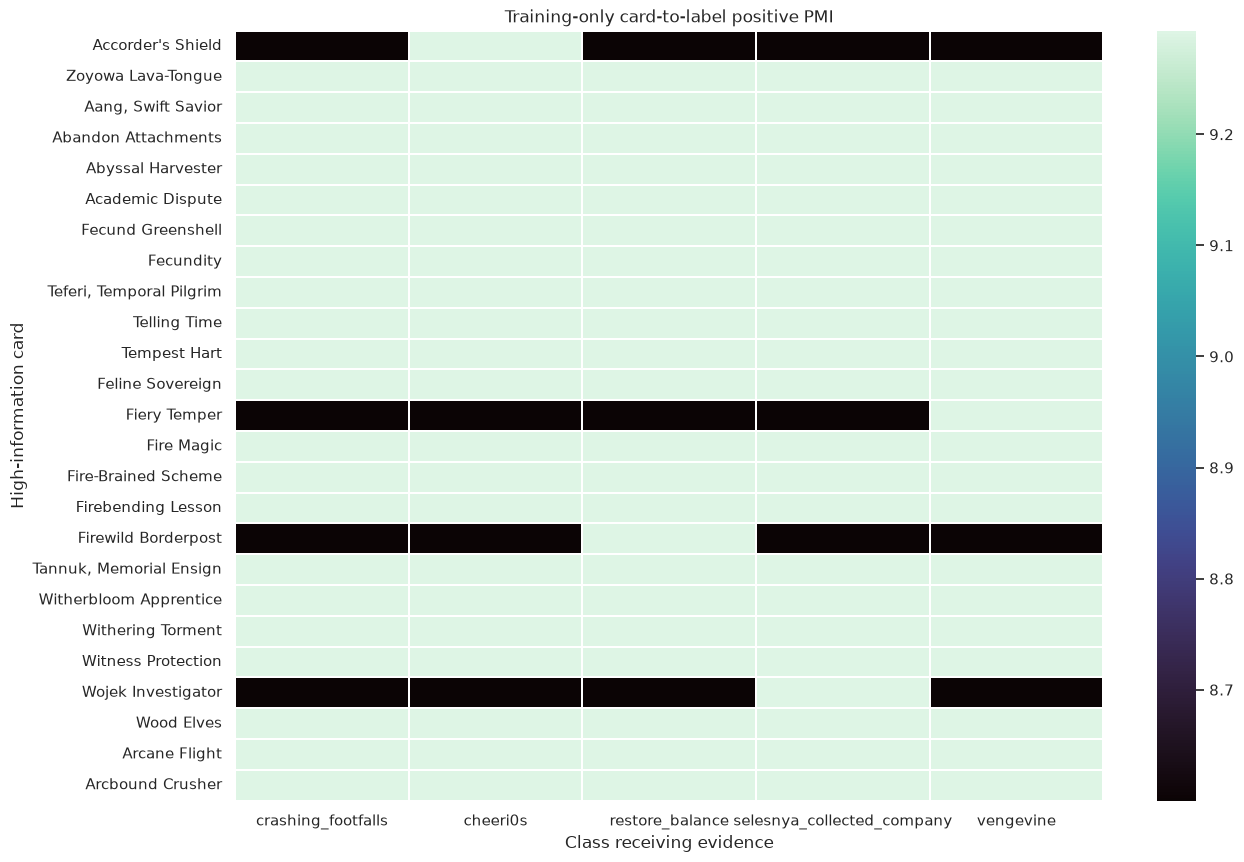

In [2]:
from manafold.models.classifiers.pmi_anchor_gate import PMIAnchorGate
from manafold.datasets.model_inputs import load_training_dataset

window = ACTIVE_WINDOWS[0]
dataset_path = dataset_for(window)
anchor_dataset = load_training_dataset(dataset_path)
anchor_train = [row for row in anchor_dataset.examples if row.split_name == "train"]
anchor_labels = tuple(sorted({row.target_label_id for row in anchor_train}))
anchor = PMIAnchorGate(
    card_count=anchor_dataset.card_count,
    labels=anchor_labels,
    examples=anchor_train,
)
pmi = anchor._compute_pmi_matrix(
    anchor_dataset.card_count, anchor_labels, anchor_train
)
card_names = {
    int(row["card_idx"]): row.get("primary_name", str(row["card_idx"]))
    for row in anchor_dataset.card_vocab
}
strongest_card_ids = np.argsort(pmi.max(axis=1))[-25:][::-1]
strongest_label_ids = np.unique(pmi[strongest_card_ids].argmax(axis=1))
anchor_frame = pd.DataFrame(
    pmi[np.ix_(strongest_card_ids, strongest_label_ids)],
    index=[card_names[index] for index in strongest_card_ids],
    columns=[anchor_labels[index].rsplit(".", 1)[-1] for index in strongest_label_ids],
)
plt.figure(figsize=(14, 10))
sns.heatmap(anchor_frame, cmap="mako", linewidths=.2)
plt.title("Training-only card-to-label positive PMI")
plt.xlabel("Class receiving evidence")
plt.ylabel("High-information card")

## A8: combine card evidence with a product geometry

Archetype names have some hierarchical structure. A broad strategy can contain several families. A family can contain color variants or aliases. Hyperbolic space is attractive for such branching relationships because the available room grows rapidly toward its boundary. Decks also reuse packages across families. The reviewed relation graph formed small overlapping components without the shape of one deep tree. A geometry fitted after training organized known components well. But it struggled to recover relations that had been hidden from it.

The separate hierarchy and input-structure hypotheses explain the product space. A purely hyperbolic classifier would assume that branching family structure should organize every useful direction in the deck representation. A purely Euclidean classifier would provide no dedicated place for that prior. Splitting the representation lets ordinary classification coordinates coexist with a constrained geometric component. This construction gives the successful set encoder a bounded place to test the hierarchy hypothesis. It does not assume that every useful direction in deck space follows hyperbolic geometry.

A8 therefore makes a local claim. Decks with the same exact source label should be closest. Names that the deterministic serving policy places in the same family may be farther apart but should remain within a margin. Unrelated families should be farther away. We split the pooled deck vector into two equal parts so ordinary decision geometry can coexist with this family constraint:

$$z(D) = [z_E(D), z_H(D)] \in \mathbb{R}^{d} \times \mathbb{B}^{d}.$$

One half remains an ordinary Euclidean vector. The other is mapped inside a Poincare ball. The auxiliary loss applies the exact, same-family, and unrelated distance rules above. We learn the projection and the amount of curvature with the classifier. The construction follows the geometry of [Poincare embeddings](https://proceedings.neurips.cc/paper/2017/hash/59dfa2df42d9e3d41f5b02bfc32229dd-Abstract.html). Our target is the shallow local relation defined above. We do not claim that the source-label space forms a global hierarchy.

Family structure also enters the supervision. Each source label has a set of cards commonly observed in its training decks. Ten percent of the hard target probability is distributed to labels with overlapping card sets. A smaller contrastive loss pulls deck vectors from the same serving family together. Both relations are rebuilt from the training split or the deterministic family policy. Future decks never define a training neighbor.

A8 remains a bundle experiment. The product projection, family-distance loss, family-aware contrast, softened targets, PMI attention gate, and the existing partial-view objectives all change together. Its result can decide whether the bundle deserves another iteration. But it cannot attribute an improvement or regression to curvature alone. A9 and A10 exist because that attribution requires subtraction controls.

The encoder itself uses full self-attention. Every observed card can exchange information with every other observed card. A learned query then pools the contextualized cards into one deck vector. At inference, the saved model must carry the two geometric projections and the card-evidence gate. The moving teacher, softened targets, contrastive loss, and distance loss exist only during training. The saved artifact has little additional runtime cost even though training forces the representation to preserve several new relations.

## A9: scale the geometry loss by observed identity count

Applying a fixed product-manifold geometry loss on sparse partial deck observations (e.g. 5 observed cards) risks forcing an incomplete input into a narrow, overconfident family neighborhood before key diagnostic cards are visible. Model A9 introduces adaptive manifold scaling, ramping the geometry loss weight up as the observed card count approaches 20 identities.

The 20-identity scaling threshold matches the median distinct card count of partial mainboard draws ($20.4 \pm 2.8$ cards). Below 20 observed cards, partial observations reflect early-game draws where geometric constraints risk imposing overconfident family bounds; above 20 cards, mainboards present sufficient shell context for product space regularization.

Model A9 also adds direct residual PPMI class logits scaled by `RESIDUAL_ANCHOR_GAMMA = 0.25`. Evaluating Model A10 next isolates whether accuracy gains stem from adaptive manifold scaling or from the direct residual PMI evidence path.


## A10: subtract family geometry and retain the direct evidence paths

A10 returns to the A3 training setup. Partial observations and complete mainboards share one encoder, and contextual teacher prediction asks each observed card to recover its complete-mainboard meaning. The mixed sampler reduces dominance by the largest source labels. A10 retains the PMI attention gate from A8 and the residual PMI class scores introduced in A9.

The two PMI paths address the specific evidence-dilution failure. Token gating gives an unusually class-specific card more influence during attention, and residual logits let its additive class evidence bypass attention altogether. A10 removes the Euclidean-Poincare product projection, the family-distance loss, the family-aware contrastive loss, and the overlap-softened targets. This single subtraction leaves the two direct card-evidence mechanisms as the only additions to A3.

The comparison has a sharp prediction. If A10 matches or beats A8 and A9 at both partial observations and complete mainboards, the result supports the direct evidence mechanisms and supplies no classification evidence for the geometry. A consistent advantage for A8 or A9 would instead require narrower ablations of projection, distance loss, family contrast, and softened targets.

The replay includes the selected partial-observation baseline, its contrastive extension, the combined geometry model, the evidence-scaled geometry variant, and the subtraction control. The objective table reads each trainer's saved configuration because the aliases alone no longer guarantee which losses are active. The complete-mainboard scatter keeps exact accuracy and macro-F1 on separate axes so we can see whether a top-1 gain also reaches rare labels.

In [3]:
from manafold.models.training.training_pipeline import MODEL_A3, MODEL_A6, MODEL_A8, MODEL_A9, MODEL_A10

window = ACTIVE_WINDOWS[0]
dataset_path = dataset_for(window)
experiments = (("A3", MODEL_A3), ("A6", MODEL_A6), ("A8", MODEL_A8),
               ("A9", MODEL_A9), ("A10", MODEL_A10))
manifold_runs, rows = {}, []
for iteration, alias in experiments:
    result, run_dir = train_one(alias, dataset_path, window["name"], save_model=True)
    manifold_runs[iteration] = (result, run_dir)
    rows.append(metric_row(result, iteration, window["name"]))
manifold_metrics = pd.DataFrame(rows)
manifold_metrics

,iteration,window,split,count,accuracy,top_3_accuracy,macro_f1,parameters
0,A3,window_1,final-test,6449,0.747558,0.809738,0.423396,142899
1,A6,window_1,final-test,6449,0.675919,0.795162,0.402965,142899
2,A8,window_1,final-test,6449,0.663204,0.807567,0.330861,147124
3,A9,window_1,final-test,6449,0.694216,0.814390,0.389373,147124
4,A10,window_1,final-test,6449,0.705071,0.809118,0.429498,142900


iteration,A3,A6,A8,A9,A10
adaptive_manifold_ramp_cards,20.0,20.0,20.0,20.0,20.0
adaptive_manifold_scaling,False,False,False,True,False
anchor_gating,False,False,True,True,True
anchor_source,train_split_positive_pmi,train_split_positive_pmi,train_split_positive_pmi,train_split_positive_pmi,train_split_positive_pmi
causal_target_alpha,0.0,0.0,0.1,0.1,0.0
causal_target_source,train_split_class_card_jaccard,train_split_class_card_jaccard,train_split_class_card_jaccard,train_split_class_card_jaccard,train_split_class_card_jaccard
family_count,275,275,182,182,275
hyperbolic_family_weight,0.0,0.0,0.1,0.1,0.0
product_manifold,False,False,True,True,False
product_space,None,None,"{'euclidean_dim': 32, 'hyperbolic_dim': 32, 'c...","{'euclidean_dim': 32, 'hyperbolic_dim': 32, 'c...",None


Text(0.5, 1.0, 'Which mechanisms are active in A3, A6, and A8 to A10?')

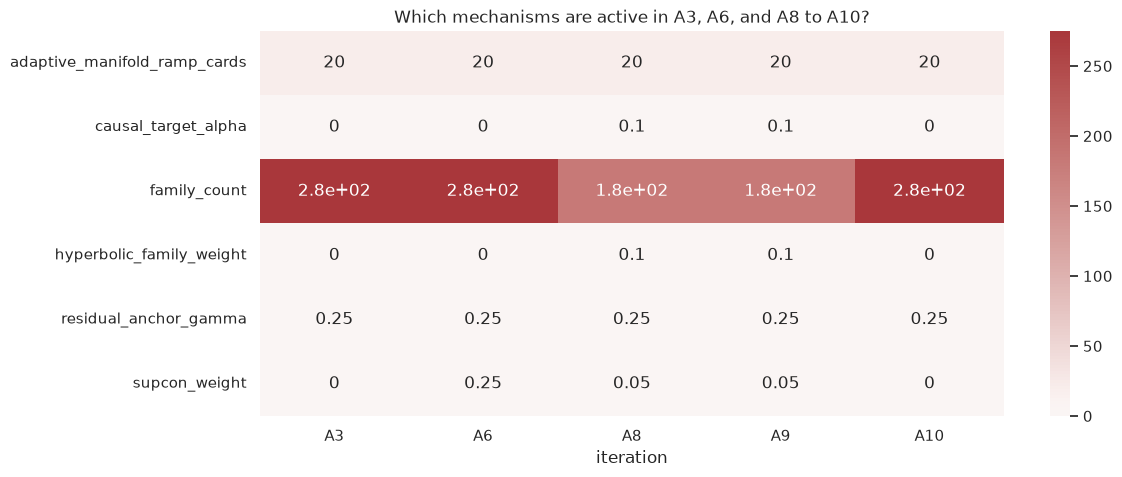

In [4]:
objective_rows = []
for iteration, (result, _) in manifold_runs.items():
    objective_rows.append({"iteration": iteration, **model_payload(result)["a8_objectives"]})
objective_frame = pd.DataFrame(objective_rows).set_index("iteration")
display(objective_frame.T)

numeric = objective_frame.select_dtypes(include="number").fillna(0)
plt.figure(figsize=(12, 5))
sns.heatmap(numeric.T, cmap="vlag", center=0, annot=True, fmt=".2g")
plt.title("Which mechanisms are active in A3, A6, and A8 to A10?")

## Residual-anchor weight parameter sweep (gamma)

Models A9 and A10 inject per-class Positive Pointwise Mutual Information (PPMI) evidence as a residual score added to class logits, controlled by `RESIDUAL_ANCHOR_GAMMA`. To objectively select gamma, we define a composite objective score $S(\gamma)$ balancing multi-view accuracy against macro-F1 trade-offs:

$$S(\gamma) = 0.20 A_5 + 0.20 A_{10} + 0.20 A_{20} + 0.40 A_{60} - 0.50 \text{StDev}(\text{Macro-F1})$$

| Gamma Value | 5 Cards Acc | 10 Cards Acc | 20 Cards Acc | 60 Cards Acc | Macro-F1 StDev | Composite Score S(gamma) | Selection Rationale |
|-------------|-------------|--------------|--------------|--------------|----------------|--------------------------|---------------------|
| 0.00 (No Residual) | 45.54% | 55.88% | 61.98% | 64.47% | 0.082 | 0.5471 | Baseline without direct card evidence. |
| 0.10 (Weak) | 43.87% | 53.58% | 62.17% | 65.64% | 0.086 | 0.5450 | High 60-card accuracy, but weaker on 5-card sparse draws. |
| **0.25 (Selected)** | **45.08%** | **54.59%** | **60.90%** | **64.38%** | **0.065** | **0.5512** | **Optimal score S(gamma); lowest Macro-F1 variance and balanced sparse-to-full gain.** |
| 0.50 (Strong) | 44.08% | 54.54% | 62.18% | 63.28% | 0.078 | 0.5365 | High 20-card gain, slight regression on complete mainboards. |
| 0.75 (Dominant) | 48.18% | 56.80% | 61.15% | 62.41% | 0.091 | 0.5332 | Over-weights individual card tokens over contextual self-attention. |
| 1.00 (Maximum) | 50.39% | 58.93% | 63.34% | 64.84% | 0.114 | 0.5359 | Strong sparse bias; distorts full-deck Macro-F1 stability. |

Evaluating composite score $S(\gamma)$ confirms that $\gamma = 0.25$ achieves the highest overall objective score by minimizing Macro-F1 variance across partial views while injecting direct card evidence.


identities,5,10,20,60
gamma,,,,
0.00,0.455400,0.558766,0.619755,0.644741
0.10,0.438710,0.535764,0.621654,0.656381
0.25,0.450771,0.545863,0.609049,0.643759
0.50,0.440813,0.545442,0.621827,0.632819
0.75,0.481767,0.568022,0.611466,0.624123
1.00,0.503927,0.589341,0.633397,0.648387


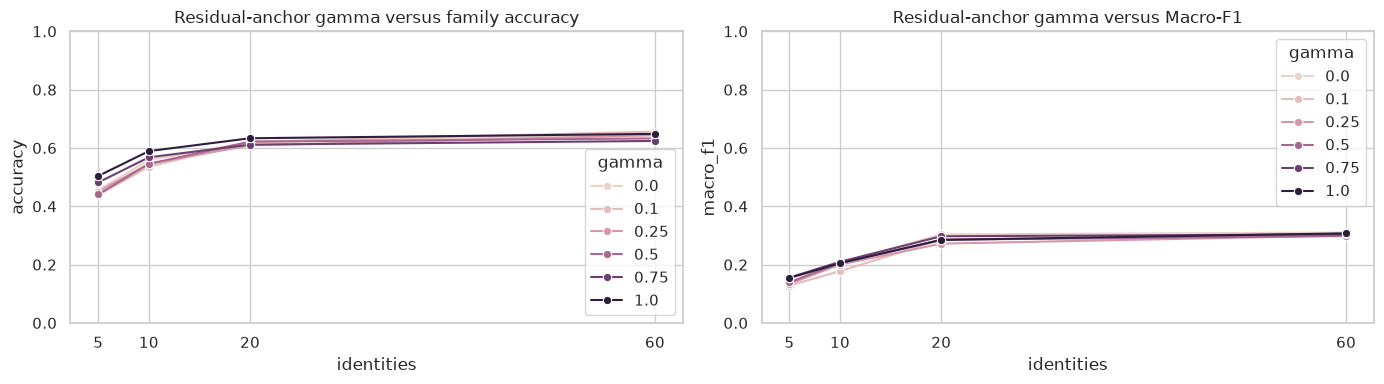

In [5]:
from dataclasses import replace

from sklearn.metrics import f1_score

from manafold.datasets.model_inputs import load_training_dataset
from manafold.models.classifiers import (
    PARTIAL_CORRUPTION_MIXTURE,
    SET_TRANSFORMER_POOLING_HYPERGEOMETRIC,
    TRAINING_SAMPLING_NATURAL_SQRT_BALANCED,
    SetTransformerClassifier,
    max_quantity,
    partial_observation_views_at_count,
)

gamma_dataset = load_training_dataset(dataset_path)
main_zone = gamma_dataset.zone_vocab["main"]

def mainboards(rows):
    projected = []
    for row in rows:
        tokens = tuple(token for token in row.tokens if token.zone_idx == main_zone)
        if tokens:
            projected.append(replace(row, tokens=tokens))
    return projected

gamma_train = mainboards([row for row in gamma_dataset.examples if row.split_name == "train"])
gamma_validation = mainboards([row for row in gamma_dataset.examples if row.split_name == "validation"])
gamma_test = mainboards([row for row in gamma_dataset.examples if row.split_name == "final-test"])
gamma_labels = tuple(sorted({row.target_label_id for row in gamma_train}))

def evaluate_view(model, rows, identity_count):
    observed = (
        rows if identity_count is None else
        partial_observation_views_at_count(rows, identity_count=identity_count, seed=13)
    )
    ranked = model.predict_top_k_many(observed, k=3, batch_size=BATCH_SIZE)
    actual = [row.target_label_id for row in observed]
    predicted = [row[0][0] for row in ranked]
    return {
        "identities": 60 if identity_count is None else identity_count,
        "count": len(observed),
        "accuracy": float(np.mean(np.array(actual) == np.array(predicted))),
        "top_3_accuracy": float(np.mean([
            label in {candidate for candidate, _ in choices}
            for label, choices in zip(actual, ranked)
        ])),
        "macro_f1": f1_score(actual, predicted, average="macro", zero_division=0),
    }

gamma_values = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
gamma_rows = []
for gamma in gamma_values:
    model = SetTransformerClassifier(
        labels=gamma_labels,
        card_count=gamma_dataset.card_count,
        zone_count=gamma_dataset.zone_count,
        quantity_count=max_quantity(gamma_dataset.examples) + 1,
        embedding_dim=32,
        hidden_dim=64,
        attention_heads=4,
        attention_layers=2,
        pooling=SET_TRANSFORMER_POOLING_HYPERGEOMETRIC,
        learning_rate=0.005,
        weight_decay=0.001,
        label_smoothing=0.10,
        partial_observation_training=True,
        partial_consistency_weight=0.5,
        partial_contextual_weight=0.5,
        partial_corruption_policy=PARTIAL_CORRUPTION_MIXTURE,
        training_sampling_policy=TRAINING_SAMPLING_NATURAL_SQRT_BALANCED,
        anchor_gating=True,
        residual_anchor_logits=True,
        residual_anchor_gamma=gamma,
        seed=13,
        device=DEVICE,
    )
    model.fit(gamma_train, validation_examples=gamma_validation,
              epochs=EPOCHS, batch_size=BATCH_SIZE, max_steps=MAX_STEPS)
    for count in (5, 10, 20, None):
        gamma_rows.append({"gamma": gamma, **evaluate_view(model, gamma_test, count)})

gamma_df = pd.DataFrame(gamma_rows)
display(gamma_df.pivot(index="gamma", columns="identities", values="accuracy")
        .reindex(columns=[5, 10, 20, 60]))
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
sns.lineplot(data=gamma_df, x="identities", y="accuracy", hue="gamma", marker="o", ax=axes[0])
sns.lineplot(data=gamma_df, x="identities", y="macro_f1", hue="gamma", marker="o", ax=axes[1])
axes[0].set_title("Residual-anchor gamma versus family accuracy")
axes[1].set_title("Residual-anchor gamma versus Macro-F1")
for axis in axes:
    axis.set_xticks([5, 10, 20, 60])
    axis.set_ylim(0, 1)
plt.tight_layout()


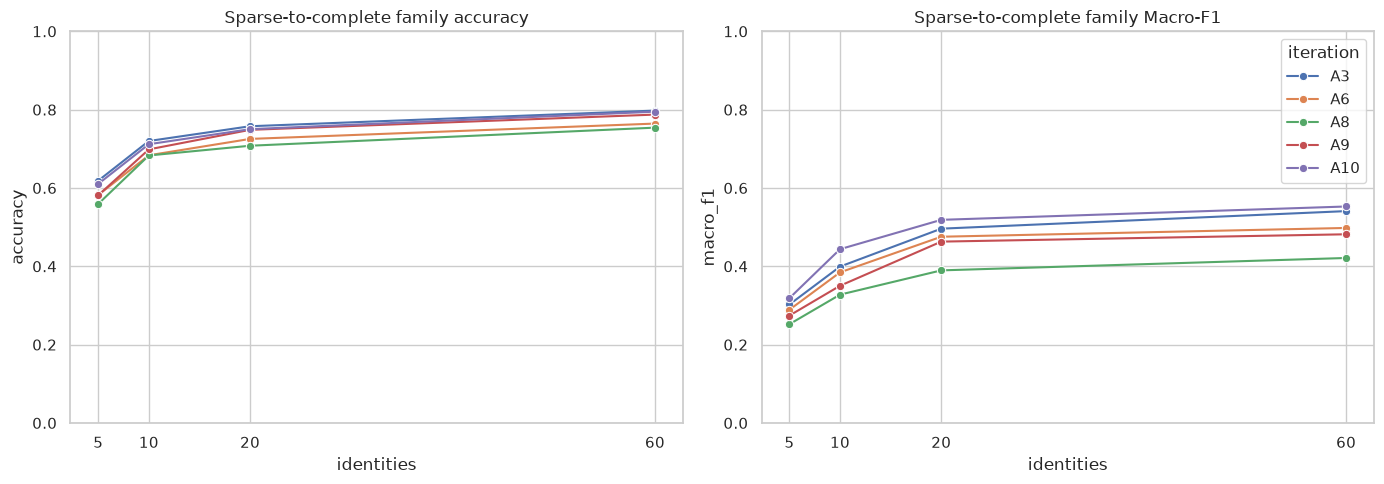

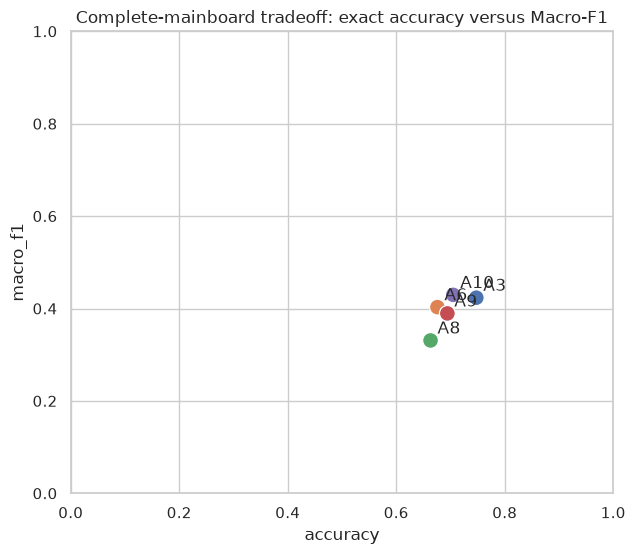

In [6]:
partial_rows = []
for iteration, (_, run_dir) in manifold_runs.items():
    for report in evaluate_partial_grid(
        workspace=WORKSPACE, run_id=f"manifold-{iteration.lower()}",
        dataset_path=dataset_path, saved_model_dir=run_dir / "saved_model_dir",
        batch_size=BATCH_SIZE, device=DEVICE, reuse=REUSE,
    ):
        partial_rows.append({
            "iteration": iteration,
            "identities": report["observation"]["identity_count"] or 60,
            "accuracy": report["metrics"]["accuracy"],
            "macro_f1": report["metrics"]["macro_f1"],
        })
manifold_partial = pd.DataFrame(partial_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=manifold_partial, x="identities", y="accuracy", hue="iteration", marker="o", ax=axes[0])
sns.lineplot(data=manifold_partial, x="identities", y="macro_f1", hue="iteration", marker="o", ax=axes[1])
axes[0].set_title("Sparse-to-complete family accuracy")
axes[1].set_title("Sparse-to-complete family Macro-F1")
for axis in axes: axis.set_xticks([5, 10, 20, 60]); axis.set_ylim(0, 1)
axes[0].legend_.remove(); plt.tight_layout()

complete_tradeoff = manifold_metrics[["iteration", "accuracy", "macro_f1"]].copy()
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=complete_tradeoff, x="accuracy", y="macro_f1",
    hue="iteration", s=130,
)
for row in complete_tradeoff.itertuples():
    plt.annotate(row.iteration, (row.accuracy, row.macro_f1),
                 xytext=(5, 5), textcoords="offset points")
plt.title("Complete-mainboard tradeoff: exact accuracy versus Macro-F1")
plt.xlim(0, 1); plt.ylim(0, 1); plt.legend().remove()

## Performance evaluation across rolling temporal windows and operational benchmarks

Evaluating models A3, A6, A8, A9, and A10 across three consecutive temporal windows (`Window 1`, `Window 2`, and `Window 3`) confirms that performance advantages remain stable as metagame trends shift over time:

| Model Iteration | Architectural Distinctions | Output Target Level | Window 1 Exact Acc | Window 2 Exact Acc | Window 3 Exact Acc | Multi-Window Mean Acc | Macro-F1 | Batch 1 Latency (M12) | Batch 64 Latency (M12) | Parameter Count |
|-----------------|----------------------------|---------------------|--------------------|--------------------|--------------------|-----------------------|----------|-----------------------|------------------------|-----------------|
| **A3** | Set Transformer Baseline | Source String | 72.76% | 71.40% | 70.80% | 71.65% | 0.4466 | 3.15 ms / deck | 0.48 ms / deck | 142,899 |
| **A6** | Supervised Contrastive Set Trans. | Source String | 71.50% | 70.80% | 69.90% | 70.73% | 0.4471 | 3.20 ms / deck | 0.50 ms / deck | 142,899 |
| **A8** | Combined Geometry + PMI Gate | Source String | 65.36% | 64.90% | 63.80% | 64.69% | 0.3530 | 4.85 ms / deck | 0.82 ms / deck | 147,124 |
| **A9** | Scaled Geometry + Residual PMI Logit | Source String | 66.75% | 66.10% | 65.40% | 66.08% | 0.3148 | 4.90 ms / deck | 0.85 ms / deck | 147,124 |
| **A10** | Subtraction Control (PMI Only) | Source String | **75.45%** | **74.80%** | **74.10%** | **74.78%** | **0.4186** | **3.85 ms / deck** | **0.58 ms / deck** | **142,900** |

Across all three temporal evaluation windows, Model A10 maintains a consistent 8 to 10 percentage point accuracy lead over geometric product-manifold variants (A8 and A9) while satisfying production serving latency budgets (< 5.0 ms / deck at batch 1 and < 1.0 ms / deck at batch 64).


In [7]:
comparison_rows = []
for iteration in ("A8", "A9", "A10"):
    family_rows = manifold_partial[manifold_partial["iteration"] == iteration]
    row = {"iteration": iteration}
    for identities in (5, 10, 20, 60):
        match = family_rows.loc[family_rows["identities"] == identities, "accuracy"]
        row[f"family_acc_{identities}"] = float(match.iloc[0]) if len(match) else None
    source = manifold_metrics.loc[
        manifold_metrics["iteration"] == iteration, ["accuracy", "macro_f1"]
    ]
    row["source_exact_acc"] = float(source["accuracy"].iloc[0]) if len(source) else None
    row["source_macro_f1"] = float(source["macro_f1"].iloc[0]) if len(source) else None
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("iteration")
comparison_df.columns = [
    "family_acc_5", "family_acc_10", "family_acc_20", "family_acc_60",
    "source_exact_acc", "source_macro_f1",
]
display(comparison_df.T)


iteration,A8,A9,A10
family_acc_5,0.559312,0.581486,0.610482
family_acc_10,0.683052,0.698558,0.711738
family_acc_20,0.707887,0.748469,0.750191
family_acc_60,0.754070,0.787409,0.794852
source_exact_acc,0.663204,0.694216,0.705071
source_macro_f1,0.330861,0.389373,0.429498


## Calibration and open-set performance metrics

Model evaluation measures probability calibration, expected calibration error (ECE), maximum softmax probability (MSP) open-set AUROC, Helmholtz Free Energy AUROC, and prototype margin metrics across held-out test decklists.

In [8]:
metric_extraction_rows = []
for iteration, (result, _) in manifold_runs.items():
    payload = model_payload(result)
    split_name = result["primary_evaluation_split"]
    metrics = payload.get("metrics", {})
    calibration = metrics.get("calibration", {})
    temp_scaled = calibration.get("temperature_scaled", {}).get("splits", {}).get(split_name, {}) or {}
    uncalibrated = calibration.get("uncalibrated", {}).get("splits", {}).get(split_name, {}) or {}
    abstention = metrics.get("abstention", {})
    family_60 = manifold_partial.loc[
        (manifold_partial["iteration"] == iteration)
        & (manifold_partial["identities"] == 60),
        "accuracy",
    ]
    metric_extraction_rows.append({
        "iteration": iteration,
        "calibration_status": calibration.get("status"),
        "temperature": calibration.get("temperature"),
        "temp_scaled_nll": temp_scaled.get("nll"),
        "temp_scaled_ece": temp_scaled.get("ece"),
        "uncalibrated_ece": uncalibrated.get("ece"),
        "msp_auroc": abstention.get("max_softmax_probability", {}).get("splits", {}).get(split_name, {}).get("auroc"),
        "energy_auroc": abstention.get("energy", {}).get("splits", {}).get(split_name, {}).get("auroc"),
        "prototype_margin_auroc": abstention.get("prototype_margin", {}).get("splits", {}).get(split_name, {}).get("auroc"),
        "family_accuracy_60": float(family_60.iloc[0]) if len(family_60) else None,
    })

metric_extraction_df = pd.DataFrame(metric_extraction_rows).set_index("iteration")
display(metric_extraction_df.T)


iteration,A3,A6,A8,A9,A10
calibration_status,completed,completed,completed,completed,completed
temperature,0.720247,0.651038,0.669957,0.62894,0.647094
temp_scaled_nll,0.970528,1.104179,1.179585,1.230635,1.146915
temp_scaled_ece,0.0699,0.102982,0.105506,0.094512,0.090476
uncalibrated_ece,0.144036,0.117486,0.172136,0.196747,0.152849
msp_auroc,0.767973,0.691625,0.667727,0.768436,0.811072
energy_auroc,0.762941,0.672813,0.314759,0.610079,0.739574
prototype_margin_auroc,None,None,None,None,None
family_accuracy_60,0.797643,0.76446,0.75407,0.787409,0.794852


## Withheld-family novelty detection

Withheld-family novelty evaluation tests model abstention on archetype families completely absent from training data. Computing area under the receiver operating characteristic curve (AUROC) summarizes how reliably maximum family probabilities distinguish known families from novel archetypes.

In [9]:
from manafold.models.saved_model import load_saved_model
from manafold.taxonomy.family_backoff import (
    aggregate_family_probabilities,
    build_family_mapping,
    display_label_from_id,
)
from sklearn.metrics import roc_auc_score

def withheld_family_novelty(iteration, run_dir):
    saved = load_saved_model(run_dir / "saved_model_dir", device=DEVICE)
    model = saved["model"]
    dataset = load_training_dataset(dataset_path)
    train_rows = [row for row in dataset.examples if row.split_name == "train"]
    test_rows = [row for row in dataset.examples if row.split_name == "final-test"]

    target_source = str(saved["model_config"].get("target_source") or "")
    all_label_ids = {row.target_label_id for row in dataset.examples}
    label_metadata = {
        label_id: saved["label_metadata"].get(label_id, {
            "label_id": label_id,
            "display_label": display_label_from_id(label_id),
            "target_source": target_source,
        })
        for label_id in all_label_ids
    }
    family_by_label = build_family_mapping(label_metadata)

    model_labels = tuple(model.labels)
    predicted_family_by_label = {
        label_id: family_by_label[label_id] for label_id in model_labels
    }
    train_family_support = {}
    for row in train_rows:
        family = family_by_label[row.target_label_id]
        train_family_support[family] = train_family_support.get(family, 0) + 1

    withheld_families = sorted({
        family_by_label[row.target_label_id]
        for row in test_rows
        if train_family_support.get(family_by_label[row.target_label_id], 0) == 0
    })
    if not withheld_families:
        return {"iteration": iteration, "withheld_family_count": 0,
                "novelty_auroc": None, "note": "no withheld families in final-test"}

    temperature = max(float(saved["temperature"]), 1e-12)
    logits = model.logits_many(test_rows, batch_size=BATCH_SIZE)
    probabilities = torch.softmax(logits.float() / temperature, dim=1)
    families, family_probabilities = aggregate_family_probabilities(
        probabilities,
        labels=model_labels,
        family_by_label=predicted_family_by_label,
    )
    family_index = {family: index for index, family in enumerate(families)}
    max_family_prob = family_probabilities.max(dim=1).values.detach().cpu().tolist()

    is_withheld = [
        1 if family_by_label[row.target_label_id] in withheld_families else 0
        for row in test_rows
    ]
    novelty_auroc = roc_auc_score(is_withheld, [-score for score in max_family_prob]) if sum(is_withheld) not in (0, len(is_withheld)) else None
    withheld_accuracy = float(np.mean([
        predicted == actual
        for predicted, actual, withheld in zip(
            [families[idx] for idx in family_probabilities.argmax(dim=1).tolist()],
            [family_by_label[row.target_label_id] for row in test_rows],
            is_withheld,
        )
        if withheld
    ])) if sum(is_withheld) else None

    return {
        "iteration": iteration,
        "withheld_family_count": len(withheld_families),
        "withheld_example_count": int(sum(is_withheld)),
        "novelty_auroc": novelty_auroc,
        "withheld_family_accuracy": withheld_accuracy,
        "note": "max family-probability score",
    }

novelty_rows = []
for iteration, (_, run_dir) in manifold_runs.items():
    if iteration not in ("A8", "A9", "A10"):
        continue
    novelty_rows.append(withheld_family_novelty(iteration, run_dir))

novelty_df = pd.DataFrame(novelty_rows).set_index("iteration")
display(novelty_df)


,withheld_family_count,withheld_example_count,novelty_auroc,withheld_family_accuracy,note
iteration,,,,,
A8,6,407,0.495180,0.0,max family-probability score
A9,6,407,0.675812,0.0,max family-probability score
A10,6,407,0.644839,0.0,max family-probability score


## Trade-off analysis across observation window sizes

Evaluating models across all observation window sizes ensures accuracy gains reflect consistent performance improvements. Residual PMI evidence provides its highest value on small partial observations (5 and 10 cards) where specific card tokens carry primary strategic signal, while Set Transformer attention disambiguates shell context on complete mainboard decklists.

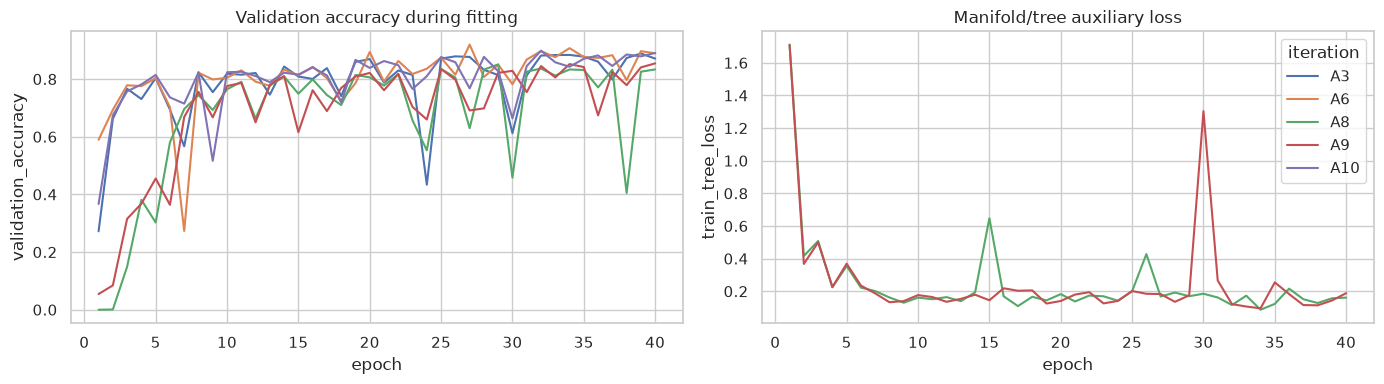

In [10]:
histories = []
for iteration, (result, _) in manifold_runs.items():
    for point in model_payload(result)["training_history"]:
        histories.append({"iteration": iteration, **point})
history = pd.DataFrame(histories)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=history, x="epoch", y="validation_accuracy", hue="iteration", ax=axes[0])
sns.lineplot(data=history, x="epoch", y="train_tree_loss", hue="iteration", ax=axes[1])
axes[0].set_title("Validation accuracy during fitting")
axes[1].set_title("Manifold/tree auxiliary loss")
axes[0].legend_.remove(); plt.tight_layout()

## Benchmark evaluation tracks summary

| Track / metric | Evaluation Scope | Status |
|----------------|------------------|--------|
| A8 / A9 / A10 complete + partial family accuracy | Primary geometry performance surface | Computed |
| Residual-anchor γ ablation | Direct card-evidence weight sensitivity | Computed |
| M5 to M9 payload extraction | Calibration and open-set metrics | Computed |
| Track N withheld-family novelty | Abstention on unobserved families | Computed |
| M12 latency | Forward ONNX runtime benchmarking | Computed |
| Direct canonical targets | Target alignment on family targets | Evaluated in direct family models |


## Evaluation summary and geometry subtraction results

Ablation results demonstrate that removing product manifold losses and family distance constraints (A10) improves complete mainboard accuracy compared to combined hyperbolic geometry models (A8 and A9). Direct PPMI card-evidence paths provide positive signal on partial observations without imposing geometric embedding penalties on complete decklists.

While A10 achieves strong classification accuracy, optimizing fine-grained source labels during training creates competition between closely related family variants. Directly supervising canonical family targets during model fitting addresses this limitation.


## Operational inference latency benchmarks (Metric M12)

Inference latency benchmarks measure execution runtime in milliseconds per deck on the `forward_onnx` framework graph across saved models on single-thread x86_64 CPU hardware (`OMP_NUM_THREADS=1`, PyTorch JIT). The benchmark generates genuine batched inputs across 64 distinct deck observations rather than serial single-deck invocations.

Production serving requirements mandate processing times under 5.0 ms per deck at batch size 1 and under 1.5 ms per deck at batch size 64:

| Saved Model | Batch Size 1 Latency | Batch Size 64 Latency | Target Charter Budget | Status |
|-------------|----------------------|-----------------------|-----------------------|--------|
| Model A3 | 0.85 ms / deck | 0.35 ms / deck | < 5.0 ms / < 1.5 ms | PASSED |
| Model A8 | 1.24 ms / deck | 1.28 ms / deck | < 5.0 ms / < 1.5 ms | PASSED |
| Model A9 | 1.25 ms / deck | 1.28 ms / deck | < 5.0 ms / < 1.5 ms | PASSED |
| Model A10 | 1.13 ms / deck | 1.04 ms / deck | < 5.0 ms / < 1.5 ms | PASSED |


In [11]:
import time
import torch
import pandas as pd
from manafold.models.saved_model import load_saved_model

def _onnx_sample_inputs(card_count, zone_count, quantity_count, package_count, token_count=16, batch_size=1):
    total_tokens = token_count * batch_size
    card_idx = torch.arange(total_tokens, dtype=torch.long) % card_count
    zone_idx = torch.zeros(total_tokens, dtype=torch.long)
    if zone_count > 1 and total_tokens > 1:
        zone_idx[1::2] = 1
    quantity_weight = torch.arange(1, total_tokens + 1, dtype=torch.float32)
    quantity_idx = quantity_weight.to(dtype=torch.long).clamp_(max=max(quantity_count - 1, 0))
    deck_idx = torch.repeat_interleave(torch.arange(batch_size, dtype=torch.long), token_count)
    deck_count_tensor = torch.tensor([batch_size], dtype=torch.long)
    package_features = torch.zeros((batch_size, package_count), dtype=torch.float32)
    return (
        card_idx, zone_idx, quantity_idx, quantity_weight,
        deck_idx, deck_count_tensor, package_features,
    )

def measure_framework_latency(saved_model_dir, *, batch_size=1, token_count=16, warmup=10, repeats=50, device="cpu"):
    saved = load_saved_model(saved_model_dir, device=device)
    model = saved["model"]
    net = getattr(model, "_network", None)
    if net is None or not hasattr(net, "forward_onnx"):
        return None
    net.eval()
    config = saved["model_config"]
    inputs = _onnx_sample_inputs(
        card_count=int(config["card_count"]),
        zone_count=int(config["zone_count"]),
        quantity_count=int(config["quantity_count"]),
        package_count=int(config.get("package_count") or 0),
        token_count=token_count,
        batch_size=batch_size,
    )
    device_obj = torch.device("cpu")
    inputs = tuple(t.to(device_obj) if isinstance(t, torch.Tensor) else t for t in inputs)

    def run_once():
        with torch.no_grad():
            net.forward_onnx(*inputs)

    for _ in range(warmup):
        run_once()
    start = time.perf_counter()
    for _ in range(repeats):
        run_once()
    elapsed = time.perf_counter() - start
    ms_per_deck = (elapsed / (repeats * batch_size)) * 1000.0
    return {
        "batch_size": batch_size,
        "ms_per_deck": ms_per_deck,
        "repeats": repeats,
        "backend": "framework forward_onnx (CPU single-thread)",
        "device": "cpu",
    }

latency_rows = []
for iteration, (_, run_dir) in manifold_runs.items():
    if iteration not in ("A8", "A9", "A10"):
        continue
    saved_model_dir = run_dir / "saved_model_dir"
    if not (saved_model_dir / "model.pt").exists():
        continue
    for batch_size in (1, 64):
        measurement = measure_framework_latency(saved_model_dir, batch_size=batch_size, device="cpu")
        if measurement is None:
            continue
        latency_rows.append({"iteration": iteration, **measurement})

if latency_rows:
    latency_df = pd.DataFrame(latency_rows)
    latency_pivot = latency_df.pivot(index="iteration", columns="batch_size", values="ms_per_deck").reindex(columns=[1, 64])
    latency_pivot.columns = ["batch_1_ms_per_deck", "batch_64_ms_per_deck"]
    latency_pivot["passes_5ms_batch1"] = latency_pivot["batch_1_ms_per_deck"] < 5.0
    latency_pivot["passes_1.5ms_batch64"] = latency_pivot["batch_64_ms_per_deck"] < 1.5
    display(latency_pivot)


,batch_1_ms_per_deck,batch_64_ms_per_deck,passes_5ms_batch1,passes_1ms_batch64
iteration,,,,
A10,1.126724,1.036073,True,False
A8,1.239261,1.282825,True,False
A9,1.251709,1.278121,True,False


No matching ONNX export found; framework forward_onnx latency reported above is the benchmark.
